# Static Labor Supply

# Setup

In [1]:
import numpy as np
from scipy.optimize import minimize

import matplotlib.pyplot as plt

from consav.linear_interp import interp_1d

## Utility and Parameters

In [ ]:
# utility
def util(h,w,N,par):
    C = income(h,w,N,par)
    return (C**(1.0+par.eta))/(1.0+par.eta) - par.beta*(h**(1.0+par.gamma))/(1.0+par.gamma)

# income. What are my net wages?
def income(h,w,N,par):
    return (1.0-par.tau)*w*h + N

# solution - what is the optimal labor supply?
def solve(w,N,par):
    obj = lambda h: -util(h,w,N,par)
    h_init = np.array([2.0]) #Initial guess on hours (2 here)

    bounds = ((0.0,200.0),)

    res = minimize(obj,h_init,bounds=bounds,method='SLSQP') #Minimize the objective function using the initial guess
    h_opt = res.x[0]
    return h_opt #What are the optimal hours

def solve_vec(N,par): #Solving for a vector of wages

    h_vec = np.nan + np.ones(par.w_grid.size)
    for iw,w in enumerate(par.w_grid):
        h_vec[iw] = solve(w,N,par)
        
    return h_vec

In [3]:
# parameters 
class par: pass
par.beta = 0.1
par.eta = -2.0
par.gamma = 2.5
par.tau = 0.1

## In-Class Exercise
1. Look at the code and talk about it with the person next to you for 5 minutes
2. Write at least one question

## Solve Static Model on Grid of Wages, $w$

In [71]:
# find optimal labor supply as a function of wages
par.w_grid = np.linspace(1.0,20.0,100)

N = 5.0 # non-labor income (unearned income). Important for strength of income effect
sol_h = solve_vec(N,par)

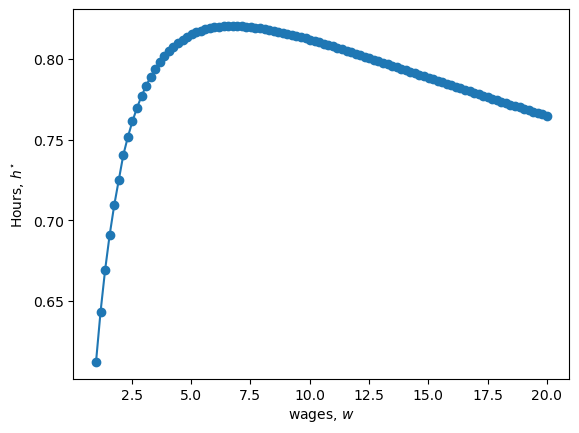

In [72]:
# plot solution
fig, ax = plt.subplots()
ax.plot(par.w_grid,sol_h,marker='o');
ax.set(xlabel='wages, $w$',ylabel='Hours, $h^{\star}$');

**Question 1:** At what level of wages does the income effect start to dominate?
- When it begins to decline. Higher wage/income means that you afford more leisure and thus work less. At this point the person would rather want to take a couple of days off. 

**Question 2:** Plot the solution for different levels of non-labor income, $N$. How does the optimal behavior change? What about the income effect?

- Non-labor income is money received from sources other than active employment, including investments (dividends, interest, rent), retirement pensions, Social Security, and government welfare. 
- Non-labor income is thus a substitute for working. If you already receive income passively, you simply don't need to sell as many hours to maintain your consumption. 
- Why do both curves slope downward at high wealth? Pure income effect. As wealth grows, you can fund consumption from your assets rather than your labor. Leisure becomes cheaper to "afford," so you buy more of it by working less.
- 

In [73]:
#fig, ax = plt.subplots()
#for N in (5.0, 0.0):
    #sol_h = solve_vec(N, par)
    #ax.plot(par.w_grid, sol_h, label=f'N={N:2.1f}', marker='o')
#ax.legend();

## Simulation
To simulate from this model, we need a level of non-labor income, $N$, and a wage level, $w$. We will primarely focus on the latter. 

The simulation here is simple, since we just need to *interpolate* the found solution for the new value of $w$ which is likely not on the grid `par.w_grid`, for which we have calculated the solution.

In [74]:
def simulate(wi,sol_h_vec,par):
    return interp_1d(par.w_grid,sol_h_vec,wi)

## Elasticities
**Marshall**

In [75]:
# Theoretical Marshall elasticities
S = ((1-par.tau)*par.w_grid*sol_h) / ((1-par.tau)*par.w_grid*sol_h + N)
ela_M = (1+par.eta*S) / (par.gamma - par.eta*S)

In [76]:
# Simulate one point on this curve. One observation is enough because no heterogeneity
w = 5.0
h_sim_base = simulate(w,sol_h,par) 
h_sim_1pct = simulate(w*1.01,sol_h,par) #Adding 1pct. to the weight and simulating the new hours

ela_M_sim = (h_sim_1pct-h_sim_base)/h_sim_base*100

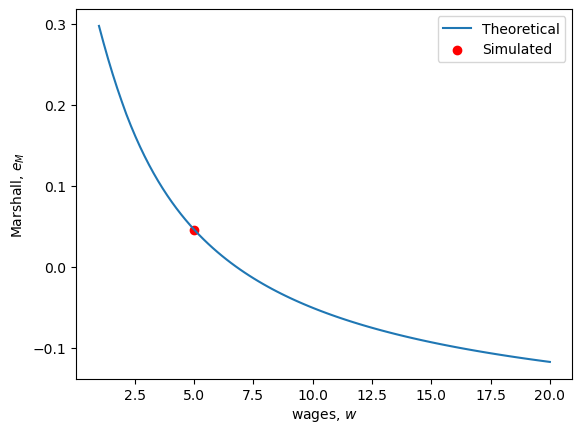

In [77]:
# plot
fig, ax = plt.subplots()
ax.plot(par.w_grid,ela_M,label='Theoretical');
ax.scatter(w,ela_M_sim,color='red',label='Simulated');
ax.set(xlabel='wages, $w$',ylabel='Marshall, $e_{M}$');
ax.legend();

**Income effect**

In [78]:
# Theoretical
ei = par.eta*S/(par.gamma - par.eta*S) 

In [79]:
# Solve and simulate model with slightly higher non-labor income
h_N = solve_vec(N * 1.01, par)
h_sim_1pct_N = simulate(w, h_N, par)

# % change in hours / % change in N (=1%) gives income elasticity
ela_I_sim = (h_sim_1pct_N - h_sim_base) / h_sim_base * 100
ei_sim = ela_I_sim / 1.0  # divide by the 1% change in N

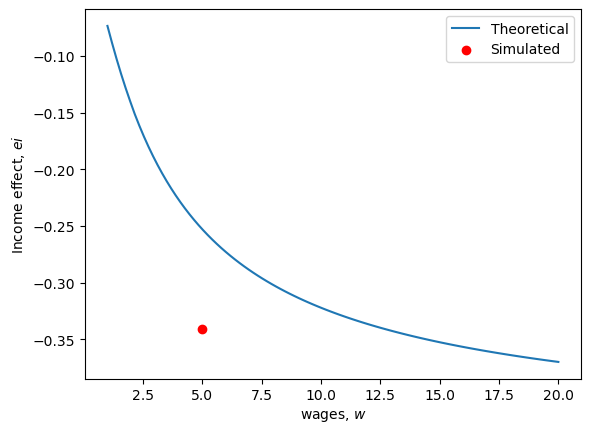

In [80]:
# plot
fig, ax = plt.subplots()
ax.plot(par.w_grid,ei,label='Theoretical');
ax.scatter(w,ei_sim,color='red',label='Simulated');
ax.set(xlabel='wages, $w$',ylabel='Income effect, $ei$');
ax.legend();

**Hicks, compensated elasticity**

In [81]:
# Theoretical
ela_H = 1/(par.gamma - par.eta*S)

In [82]:
# Hicks: Compensate (or use Slutsky, which is much easier)
def util_diff(comp,h_base,w,N,par):
    
    util_base = util(h_base,w,N,par)
    
    # alternative model: increase wage by 1% but compensate via non-labor income
    N_alt = N + comp
    w_alt = w*1.01
    
    h_alt = solve(w_alt,N_alt,par)
    util_alt = util(h_alt,w_alt,N_alt,par)
    
    return util_base - util_alt #We want to get this compensation to zero to find the correct compensation level

In [83]:
# find the compensation that equalize utility to baseline level
obj = lambda comp: 1000.0*util_diff(comp,h_sim_base,w,N,par)**2 # squared utility difference (scaled)
res = minimize(obj,0.0)
comp = res.x[0]

print(f'Compensation: {comp:2.4f}. Resulting utility difference: {util_diff(comp,h_sim_base,w,N,par):2.2g}')

Compensation: -0.0367. Resulting utility difference: 1.1e-10


In [84]:
# calculate elasticity with this level of compensation
h_sim_1pct_H = solve(w*1.01,N+comp,par)
ela_H_sim = (h_sim_1pct_H-h_sim_base)/h_sim_base*100

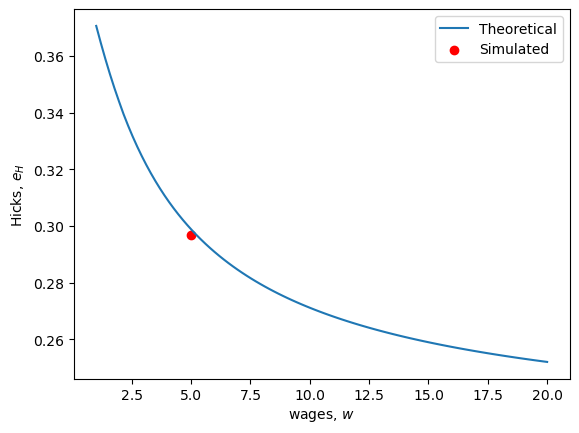

In [85]:
# plot
fig, ax = plt.subplots()
ax.plot(par.w_grid,ela_H,label='Theoretical');
ax.scatter(w,ela_H_sim,color='red',label='Simulated');
ax.set(xlabel='wages, $w$',ylabel='Hicks, $e_H$');
ax.legend();

## In-Class Exercise
Imagine that there is 1,000 heterogeneous agents with individual levels of wages, $w_i$ for $i=1,\dots,1,000$. The distribution of wages is uniform on $[2.5,10.0]$. 

What is the average Marshall elasticity in the population? <br>
\[*hint:* you can calculate this by simulation using `np.randon.uniform`\]

## solution

In [96]:
# solution
n = 1_000

# draw uniform wages
np.random.seed(2023)
wi = np.random.uniform(2.5,10.0,size=n)

# find baseline optimal labor supply and alternative
hi_base = np.nan + np.ones(n) #np.nan + np.ones(n) is a way to initialize an array of size n with NaN values. This is useful to indicate that the values have not been computed yet.
hi_1pct = np.nan + np.ones(n)
for i in range(n):
    hi_base[i] = simulate(wi[i],sol_h,par)
    hi_1pct[i] = simulate(wi[i]*1.01,sol_h,par)
    
# individual elasticities
ela_M_i = (hi_1pct-hi_base)/hi_base*100

# average
print(f'Average Marshall: {np.mean(ela_M_i):2.3f}')

Average Marshall: 0.021


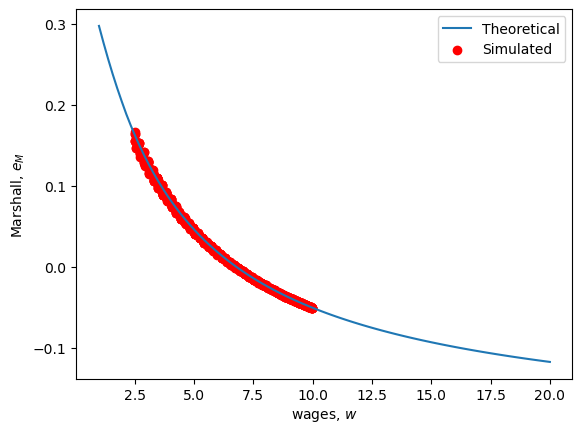

In [95]:
# plot individual with theoretical
fig, ax = plt.subplots()
ax.plot(par.w_grid,ela_M,label='Theoretical');
ax.scatter(wi,ela_M_i,color='red',label='Simulated');
ax.set(xlabel='wages, $w$',ylabel='Marshall, $e_{M}$');
ax.legend();